# FishWood — CDF weight refinement vs equal-spaced weights
The FishWood MDP follows [MO-Gymnasium FishWood](https://mo-gymnasium.farama.org/environments/fishwood/) (see source: two states, two actions, next state equals action; expected rewards use `fishproba` / `woodproba`).

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from scipy.interpolate import PchipInterpolator

DEVICE = "cpu"
FIG_PATH = "figure/"
os.makedirs(FIG_PATH, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (7, 5),
    "figure.dpi": 120,
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "legend.fontsize": 12,
    "lines.linewidth": 2.0,
    "lines.markersize": 8,
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.5,
    "legend.frameon": False,
    "figure.autolayout": True,
})

## A. Tabular FishWood model (expected rewards)

State `0`: fishing; state `1`: woods. Reward is drawn in the **current** state, then `next_state = action` (0 = go fish, 1 = collect wood). We use expectations so $R$ is deterministic (same convention as using a large-horizon discounted surrogate).

In [7]:
def build_fishwood_tabular_model(fishproba=0.1, woodproba=0.9):
    """
    S=2 (0 fish, 1 woods), A=2. Transition: s' = a with probability 1.
    R[s,a,0] = fish rate in state 0, else 0; R[s,a,1] = wood rate in state 1, else 0.
    Initial state: woods (index 1).
    """
    S, A = 2, 2
    P = np.zeros((S, A, S), dtype=np.float32)
    for s in range(S):
        for a in range(A):
            P[s, a, a] = 1.0
    R = np.zeros((S, A, 2), dtype=np.float32)
    R[0, :, 0] = float(fishproba)
    R[1, :, 1] = float(woodproba)
    rho0 = np.array([0.0, 1.0], dtype=np.float32)
    return {"S": S, "A": A, "P": P, "R": R, "rho0": rho0, "fishproba": fishproba, "woodproba": woodproba}


def build_fishwood_model_from_mogym(env_id="fishwood-v0", fishproba=0.1, woodproba=0.9):
    """
    Prefer the official environment constructor, then convert to the same tabular expected model.
    Falls back to direct tabular build if mo_gymnasium is unavailable.
    """
    try:
        import mo_gymnasium as mo_gym
        env = mo_gym.make(env_id, fishproba=fishproba, woodproba=woodproba)
        uenv = env.unwrapped
        fp = float(getattr(uenv, "_fishproba", fishproba))
        wp = float(getattr(uenv, "_woodproba", woodproba))
        env.close()
        return build_fishwood_tabular_model(fishproba=fp, woodproba=wp)
    except Exception as e:
        print(f"[info] mo_gymnasium not available or failed ({e}); using direct tabular FishWood model.")
        return build_fishwood_tabular_model(fishproba=fishproba, woodproba=woodproba)


def make_equispace_pi_ref(S, A):
    return np.full((S, A), 1.0 / A, dtype=np.float32)


def discounted_state_dist_from_policy_torch(pi, P_t, rho0_t, gamma):
    P_pi = torch.einsum("sa,san->sn", pi, P_t)
    I = torch.eye(P_pi.shape[0], dtype=P_pi.dtype, device=P_pi.device)
    M = I - gamma * P_pi
    rhs = (1.0 - gamma) * rho0_t
    d = torch.linalg.solve(M.T, rhs)
    return d


def evaluate_policy_torch(logits, P_t, R_t, rho0_t, gamma, tau, pi_ref_t):
    pi = F.softmax(logits, dim=-1)
    d = discounted_state_dist_from_policy_torch(pi, P_t, rho0_t, gamma)
    mu = d.unsqueeze(-1) * pi
    R1 = torch.sum(mu * R_t[..., 0])
    R2 = torch.sum(mu * R_t[..., 1])
    log_pi = torch.log(pi + 1e-12)
    log_pi_ref = torch.log(pi_ref_t + 1e-12)
    kl_state = torch.sum(pi * (log_pi - log_pi_ref), dim=-1)
    reg = tau * torch.sum(d * kl_state)
    return {"pi": pi, "d": d, "mu": mu, "R1": R1, "R2": R2, "reg": reg, "obj_vec": torch.stack([R1, R2])}


def scalarized_objective_torch(logits, w, P_t, R_t, rho0_t, gamma, tau, pi_ref_t):
    out = evaluate_policy_torch(logits, P_t, R_t, rho0_t, gamma, tau, pi_ref_t)
    scalar = (1.0 - w) * out["R1"] + w * out["R2"] - out["reg"]
    return scalar, out


def solve_policy_scalarization(
    w, P, R, rho0, gamma, tau, pi_ref,
    logits_init=None, lr=0.05, maxiter=400, tol=1e-8, device=DEVICE, verbose=False,
):
    P_t = torch.tensor(P, dtype=torch.float32, device=device)
    R_t = torch.tensor(R, dtype=torch.float32, device=device)
    rho0_t = torch.tensor(rho0, dtype=torch.float32, device=device)
    pi_ref_t = torch.tensor(pi_ref, dtype=torch.float32, device=device)
    S, A = pi_ref.shape
    if logits_init is None:
        logits = torch.zeros((S, A), dtype=torch.float32, device=device, requires_grad=True)
    else:
        logits = torch.tensor(logits_init, dtype=torch.float32, device=device, requires_grad=True)
    opt = torch.optim.Adam([logits], lr=lr)
    prev_val = None
    for it in range(maxiter):
        opt.zero_grad()
        scalar, out = scalarized_objective_torch(logits, w, P_t, R_t, rho0_t, gamma, tau, pi_ref_t)
        (-scalar).backward()
        opt.step()
        val = scalar.item()
        if prev_val is not None and abs(val - prev_val) < tol:
            break
        prev_val = val
    with torch.no_grad():
        scalar, out = scalarized_objective_torch(logits, w, P_t, R_t, rho0_t, gamma, tau, pi_ref_t)
    return {
        "w": w,
        "logits": logits.detach().cpu().numpy(),
        "pi": out["pi"].detach().cpu().numpy(),
        "R1": out["R1"].item(),
        "R2": out["R2"].item(),
        "reg": out["reg"].item(),
        "scalar": scalar.item(),
    }

## B. CDF refinement (arc-length on objective polyline) + equal-spaced baseline

In [15]:
def policy_from_mu(mu, pi_ref, d_eps=1e-12, tiny=1e-32):
    mu = np.asarray(mu, dtype=np.float64)
    pi_ref = np.asarray(pi_ref, dtype=np.float64)
    d = mu.sum(axis=1)
    pi = np.array(pi_ref, copy=True)
    active = d > d_eps
    pi[active] = mu[active] / d[active, None]
    pi = np.clip(pi, tiny, 1.0)
    pi = pi / pi.sum(axis=1, keepdims=True)
    return pi, d


def logits_from_policy(pi, tiny=1e-32):
    pi = np.clip(np.asarray(pi, dtype=np.float64), tiny, 1.0)
    logits = np.log(pi)
    return logits - logits.mean(axis=1, keepdims=True)


def solve_cdf_refinement_policy(
    N_points, P, R, rho0, gamma, tau, pi_ref,
    max_outer_iters=12, alpha=0.8,
    inner_maxiter=400, inner_lr=0.05, inner_tol=1e-8,
    logits0=None, logits1=None, mu0=None, mu1=None,
    d_eps=1e-12, init_from_prev=True, device=DEVICE, verbose=False,
):
    quantiles = np.linspace(0.0, 1.0, N_points)
    fine_w = np.linspace(0.0, 1.0, 2001)
    F_vals = fine_w.copy()
    F_history = [F_vals.copy()]
    S, A = pi_ref.shape
    current_logits = [None for _ in range(N_points)]

    if mu0 is not None and mu1 is not None:
        mu0 = np.asarray(mu0, dtype=np.float64)
        mu1 = np.asarray(mu1, dtype=np.float64)
        for i, q in enumerate(quantiles):
            mu_q = np.maximum((1.0 - q) * mu0 + q * mu1, 0.0)
            pi_q, _ = policy_from_mu(mu_q, pi_ref, d_eps=d_eps)
            current_logits[i] = logits_from_policy(pi_q)
    elif logits0 is not None and logits1 is not None:
        current_logits = [(1.0 - q) * logits0 + q * logits1 for q in quantiles]

    pf_history = []
    policy_history = []
    weight_history = []

    for t in range(max_outer_iters):
        current_w = np.interp(quantiles, F_vals, fine_w)
        weight_history.append(current_w.copy())
        if verbose:
            print(f"--- outer {t} ---\nweights:", np.round(current_w, 4))

        results_t = []
        f_coords = []
        for n, w in enumerate(current_w):
            if init_from_prev and current_logits[n] is not None:
                logits_init = current_logits[n]
            elif logits0 is not None and logits1 is not None:
                logits_init = (1.0 - w) * logits0 + w * logits1
            else:
                logits_init = np.zeros((S, A), dtype=np.float32)

            sol = solve_policy_scalarization(
                w, P, R, rho0, gamma, tau, pi_ref,
                logits_init=logits_init, lr=inner_lr, maxiter=inner_maxiter, tol=inner_tol, device=device, verbose=False,
            )
            current_logits[n] = sol["logits"]
            results_t.append(sol)
            f_coords.append([sol["R1"], sol["R2"]])

        f_coords = np.asarray(f_coords, dtype=np.float32)
        pf_history.append(f_coords)
        policy_history.append(results_t)

        diffs = np.diff(f_coords, axis=0)
        seg_lens = np.sqrt(np.sum(diffs ** 2, axis=1))
        s_vals = np.concatenate([[0.0], np.cumsum(seg_lens)])
        total_len = s_vals[-1]
        if total_len <= 1e-14:
            break
        tilde_F_values = s_vals / total_len
        interp_tilde_F = PchipInterpolator(current_w, tilde_F_values)
        tilde_vals = interp_tilde_F(fine_w)
        F_vals = (1.0 - alpha) * F_vals + alpha * tilde_vals
        F_vals = np.maximum.accumulate(F_vals)
        F_vals[0] = 0.0
        F_vals[-1] = 1.0
        F_history.append(F_vals.copy())

    final_w = np.interp(quantiles, F_vals, fine_w)
    return {
        "final_w": final_w,
        "final_logits": current_logits,
        "pf_history": pf_history,
        "policy_history": policy_history,
        "weight_history": weight_history,
        "F_history": F_history,
        "F_grid_w": fine_w,
        "F_grid_vals": F_vals,
    }


def run_equispace_weights_policy_baseline(
    N_points, P, R, rho0, gamma, tau, pi_ref,
    inner_maxiter=400, inner_lr=0.05, inner_tol=1e-8, device=DEVICE,
):
    weights = np.linspace(0.0, 1.0, N_points)
    results = []
    pf = []
    for w in weights:
        sol = solve_policy_scalarization(
            w, P, R, rho0, gamma, tau, pi_ref,
            logits_init=None, lr=inner_lr, maxiter=inner_maxiter, tol=inner_tol, device=device, verbose=False,
        )
        results.append(sol)
        pf.append([sol["R1"], sol["R2"]])
    return {"weights": weights, "results": results, "pf": np.asarray(pf, dtype=np.float64)}

## C. Run experiment and plot Pareto-front coverage

Dense equal-weight sweep serves as a visual reference for the frontier. CDF refinement re-allocates the same number of scalarizations along arc length in return space.

In [43]:
fishproba, woodproba = 0.2, 0.8
model = build_fishwood_model_from_mogym("fishwood-v0", fishproba=fishproba, woodproba=woodproba)
P, R, rho0 = model["P"], model["R"], model["rho0"]
S, A = model["S"], model["A"]
gamma = 0.995
tau = 0.5
pi_ref = make_equispace_pi_ref(S, A)

N_sparse = 7
N_ref = 201

# Endpoints for logit interpolation init (optional)
sol_w0 = solve_policy_scalarization(0.0, P, R, rho0, gamma, tau, pi_ref)
sol_w1 = solve_policy_scalarization(1.0, P, R, rho0, gamma, tau, pi_ref)
logits0, logits1 = sol_w0["logits"], sol_w1["logits"]

out_dense = run_equispace_weights_policy_baseline(
    N_ref, P, R, rho0, gamma, tau, pi_ref, inner_maxiter=100, inner_lr=0.05,
)
pf_ref = out_dense["pf"]

out_equi = run_equispace_weights_policy_baseline(
    N_sparse, P, R, rho0, gamma, tau, pi_ref, inner_maxiter=100, inner_lr=0.05,
)

out_cdf = solve_cdf_refinement_policy(
    N_sparse, P, R, rho0, gamma, tau, pi_ref,
    max_outer_iters=30, alpha=0.8,
    logits0=logits0, logits1=logits1, init_from_prev=True, verbose=True,
)
pf_cdf = out_cdf["pf_history"][-1]

# fig, ax = plt.subplots()
# ax.plot(pf_ref[:, 0], pf_ref[:, 1], color="0.75", lw=3, label="Reference PF (equi $w$, dense)")
# ax.scatter(out_equi["pf"][:, 0], out_equi["pf"][:, 1], s=80, marker="s", c="#d62728", zorder=5, label=f"Equal-spaced $w$ ($N={N_sparse}$)")
# ax.scatter(pf_cdf[:, 0], pf_cdf[:, 1], s=70, c="#1f77b4", zorder=6, label=f"CDF refinement ($N={N_sparse}$)")
# for i in range(len(pf_cdf)):
#     ax.annotate(str(i), (pf_cdf[i, 0], pf_cdf[i, 1]), textcoords="offset points", xytext=(4, 4), fontsize=8, color="#1f77b4")
# ax.set_xlabel(r"Expected discounted fish ($R_1$)")
# ax.set_ylabel(r"Expected discounted wood ($R_2$)")
# ax.set_title(f"FishWood PF coverage ($\\gamma={gamma}$, $\\tau={tau}$, fish={fishproba}, wood={woodproba})")
# ax.legend(loc="best")
# fp = FIG_PATH + "fishwood_pf_coverage.pdf"
# plt.savefig(fp, bbox_inches="tight")
# plt.show()
# print("Saved", fp)

--- outer 0 ---
weights: [0.     0.1667 0.3333 0.5    0.6667 0.8333 1.    ]
--- outer 1 ---
weights: [0.     0.1498 0.2987 0.4523 0.6119 0.7901 1.    ]
--- outer 2 ---
weights: [0.     0.1469 0.2942 0.441  0.5999 0.7798 1.    ]
--- outer 3 ---
weights: [0.     0.1464 0.2911 0.4387 0.5976 0.775  1.    ]
--- outer 4 ---
weights: [0.     0.1462 0.2902 0.4379 0.596  0.776  1.    ]
--- outer 5 ---
weights: [0.     0.1463 0.2897 0.4381 0.5966 0.7772 1.    ]
--- outer 6 ---
weights: [0.     0.1465 0.2904 0.4383 0.5971 0.7775 1.    ]
--- outer 7 ---
weights: [0.     0.1458 0.2904 0.4382 0.5971 0.7776 1.    ]
--- outer 8 ---
weights: [0.     0.146  0.2903 0.4382 0.597  0.7775 1.    ]
--- outer 9 ---
weights: [0.     0.1458 0.29   0.438  0.5968 0.7773 1.    ]
--- outer 10 ---
weights: [0.     0.1462 0.2902 0.4381 0.5969 0.7774 1.    ]
--- outer 11 ---
weights: [0.     0.1467 0.2904 0.4383 0.5971 0.7775 1.    ]
--- outer 12 ---
weights: [0.     0.1464 0.2904 0.4383 0.5971 0.7775 1.    ]
--- outer

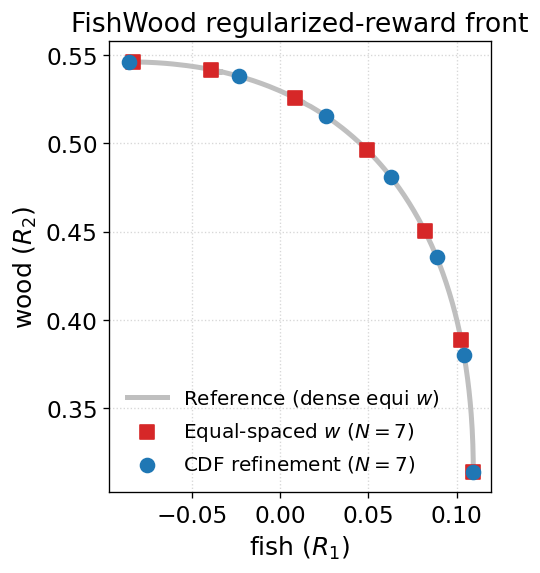

In [44]:

def to_reg_points(results):
    arr = []
    for s in results:
        arr.append([s["R1"] - s["reg"], s["R2"] - s["reg"]])
    return np.asarray(arr, dtype=np.float64)

pf_ref_reg = to_reg_points(out_dense["results"])
pf_equi_reg = to_reg_points(out_equi["results"])
pf_cdf_reg = to_reg_points(out_cdf["policy_history"][-1])

fig, ax = plt.subplots()
ax.plot(pf_ref_reg[:, 0], pf_ref_reg[:, 1], color="0.75", lw=3, label="Reference (dense equi $w$)")
ax.scatter(pf_equi_reg[:, 0], pf_equi_reg[:, 1], s=80, marker="s", c="#d62728", zorder=5, label=f"Equal-spaced $w$ ($N={N_sparse}$)")
ax.scatter(pf_cdf_reg[:, 0], pf_cdf_reg[:, 1], s=70, c="#1f77b4", zorder=6, label=f"CDF refinement ($N={N_sparse}$)")

ax.set_xlabel(r"fish ($R_1 $)")
ax.set_ylabel(r"wood ($R_2 $)")
ax.set_title("FishWood regularized-reward front")
ax.legend(loc="best")
ax.set_aspect('equal', adjustable='box')
fp3 = FIG_PATH + "fishwood_pf_coverage.pdf"
# plt.savefig(fp3, bbox_inches="tight")
# plt.show()
# print("Saved", fp3)

In [24]:
# # Evolution: Pareto sets across CDF outer iterations
# fig, ax = plt.subplots()
# cmap = plt.cm.viridis
# n_it = len(out_cdf["pf_history"])
# for t, pf_t in enumerate(out_cdf["pf_history"]):
#     col = cmap(t / max(n_it - 1, 1))
#     ax.scatter(pf_t[:, 0], pf_t[:, 1], s=40, color=col, alpha=0.85, label=None)
# ax.plot(pf_ref[:, 0], pf_ref[:, 1], color="0.5", ls="--", lw=2, label="Dense reference")
# sm = plt.cm.ScalarMappable(norm=plt.Normalize(0, n_it - 1), cmap=cmap)
# sm.set_array([])
# cb = plt.colorbar(sm, ax=ax)
# cb.set_label("CDF outer iteration")
# ax.set_xlabel(r"$R_1$ (fish)")
# ax.set_ylabel(r"$R_2$ (wood)")
# ax.set_title("CDF refinement: PF snapshots")
# ax.legend(loc="best")
# fp2 = FIG_PATH + "fishwood_pf_cdf_iterations.pdf"
# # plt.savefig(fp2, bbox_inches="tight")
# # plt.show()
# print("Saved", fp2)